In [1]:
# 1. Imports and Setup

# %%
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy
import os

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATv2Conv, Linear

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition

from imblearn.over_sampling import SMOTENC   # for SMOTE with mixed data types

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


In [2]:
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 
                'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
                'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

print("Data loaded.")
print("TCGA shape:", tcga_df.shape)
print("CGGA shape:", cgga_df.shape)

Data loaded.
TCGA shape: (839, 24)
CGGA shape: (286, 24)


In [3]:
# First split: 80% train, 20% test
train_df, test_df = train_test_split(
    tcga_df, 
    test_size=0.2, 
    stratify=tcga_df['Grade'], 
    random_state=42
)
print("After first split (80% train / 20% test):")
print(f"  Intermediate train size: {len(train_df)}")
print(f"  Test size: {len(test_df)}")
print("  Train class distribution:")
print(train_df['Grade'].value_counts())
print()

# Second split: further split training into final train (80%) and validation (20%)
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['Grade'], 
    random_state=42
)
print("After inner split (80% of train / 20% of train):")
print(f"  Final train size: {len(train_df)}")
print(f"  Validation size: {len(val_df)}")
print("  Final train class distribution (before balancing):")
print(train_df['Grade'].value_counts())
print()
print(f"Total patients accounted for: {len(train_df) + len(val_df) + len(test_df)} (should equal {len(tcga_df)})")

After first split (80% train / 20% test):
  Intermediate train size: 671
  Test size: 168
  Train class distribution:
Grade
0    389
1    282
Name: count, dtype: int64

After inner split (80% of train / 20% of train):
  Final train size: 536
  Validation size: 135
  Final train class distribution (before balancing):
Grade
0    311
1    225
Name: count, dtype: int64

Total patients accounted for: 839 (should equal 839)


In [4]:
# Metadata for CTGAN
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    metadata.update_column(column_name=col, sdtype='categorical')

# Determine minority class and needed samples
class_counts = train_df['Grade'].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
samples_needed = class_counts[majority_class] - class_counts[minority_class]

print(f"CTGAN: Generating {samples_needed} synthetic minority samples...")
synthesizer = CTGANSynthesizer(metadata, epochs=150, batch_size=50, verbose=False, cuda=True)
synthesizer.fit(train_df)

condition = Condition(num_rows=samples_needed, column_values={'Grade': minority_class})
synthetic_samples = synthesizer.sample_from_conditions(conditions=[condition])

train_ctgan_df = pd.concat([train_df, synthetic_samples], ignore_index=True)
print("CTGAN-balanced training set created.")
print(train_ctgan_df['Grade'].value_counts())
print()

CTGAN: Generating 86 synthetic minority samples...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 434.24it/s]

CTGAN-balanced training set created.
Grade
0    311
1    311
Name: count, dtype: int64



In [5]:
# Features and target for SMOTE
feature_columns = gene_columns + ['Gender', 'Race', 'Age_at_diagnosis']
X_train = train_df[feature_columns]
y_train = train_df['Grade']

# Indices of categorical features (all gene columns + Gender, Race)
categorical_indices = [i for i, col in enumerate(feature_columns) 
                       if col in gene_columns or col in ['Gender', 'Race']]

# Apply SMOTENC
smote = SMOTENC(categorical_features=categorical_indices, random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Create balanced dataframe
train_smote_df = pd.DataFrame(X_res, columns=feature_columns)
train_smote_df['Grade'] = y_res

# Gene columns should remain binary; round to 0/1 if needed (SMOTE may create fractions)
for col in gene_columns:
    train_smote_df[col] = train_smote_df[col].round().astype(int)

print("SMOTE-balanced training set created.")
print(train_smote_df['Grade'].value_counts())
print()

SMOTE-balanced training set created.
Grade
0    311
1    311
Name: count, dtype: int64



In [6]:
# 5. Graph Construction Function

# %%
def construct_bipartite_heterograph(df):
    """Build a heterogeneous graph with Patient and Gene nodes, including reverse edges."""
    graph = HeteroData()
    
    # Patient features: Gender, Race, Age (normalized)
    scaler = StandardScaler()
    age_norm = scaler.fit_transform(df[['Age_at_diagnosis']])
    patient_feats = np.hstack([df[['Gender', 'Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(patient_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    
    # Gene nodes: one‑hot identity
    num_genes = len(gene_columns)
    graph['Gene'].x = torch.eye(num_genes, dtype=torch.float)
    
    # Edge lists (Gene -> Patient)
    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx)
                dst_patients.append(p_idx)
    
    # Forward edges (Gene -> Patient)
    graph['Gene', 'mutates', 'Patient'].edge_index = torch.tensor([src_genes, dst_patients], dtype=torch.long)
    # Reverse edges (Patient -> Gene)
    graph['Patient', 'mutated_by', 'Gene'].edge_index = torch.tensor([dst_patients, src_genes], dtype=torch.long)
    
    return graph

In [7]:
#6. Build All Graphs

# %%
# Training graphs
tcga_train_no_bal = construct_bipartite_heterograph(train_df).to(device)
tcga_train_ctgan  = construct_bipartite_heterograph(train_ctgan_df).to(device)
tcga_train_smote  = construct_bipartite_heterograph(train_smote_df).to(device)

# Validation and test graphs (same for all)
tcga_val   = construct_bipartite_heterograph(val_df).to(device)
tcga_test  = construct_bipartite_heterograph(test_df).to(device)
cgga_graph = construct_bipartite_heterograph(cgga_df).to(device)

print("Graphs built:")
print(f"  No bal train: {tcga_train_no_bal['Patient'].x.shape[0]} patients")
print(f"  CTGAN train : {tcga_train_ctgan['Patient'].x.shape[0]} patients")
print(f"  SMOTE train : {tcga_train_smote['Patient'].x.shape[0]} patients")
print(f"  Val         : {tcga_val['Patient'].x.shape[0]} patients")
print(f"  Test        : {tcga_test['Patient'].x.shape[0]} patients")
print(f"  CGGA        : {cgga_graph['Patient'].x.shape[0]} patients")


Graphs built:
  No bal train: 536 patients
  CTGAN train : 622 patients
  SMOTE train : 622 patients
  Val         : 135 patients
  Test        : 168 patients
  CGGA        : 286 patients


In [8]:
# 7. Model Definition (Heterogeneous GATv2)

# %%
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=8, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        
        self.patient_lin = Linear(-1, hidden_dim)
        self.gene_lin = Linear(-1, hidden_dim)
        
        self.conv_gene_to_patient = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.conv_patient_to_gene = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        
        self.patient_skip = Linear(hidden_dim, hidden_dim)
        self.gene_skip = Linear(hidden_dim, hidden_dim)
        
        self.classifier = Linear(hidden_dim, out_dim)

    def forward(self, x_dict, edge_index_dict):
        h_patient = F.relu(self.patient_lin(x_dict['Patient']))
        h_gene = F.relu(self.gene_lin(x_dict['Gene']))
        
        out_patient = self.conv_gene_to_patient((h_gene, h_patient), edge_index_dict[('Gene', 'mutates', 'Patient')])
        out_gene = self.conv_patient_to_gene((h_patient, h_gene), edge_index_dict[('Patient', 'mutated_by', 'Gene')])
        
        h_patient = self.patient_skip(h_patient) + out_patient
        h_gene = self.gene_skip(h_gene) + out_gene
        
        h_patient = F.dropout(F.leaky_relu(h_patient, 0.2), self.dropout, training=self.training)
        h_gene = F.dropout(F.leaky_relu(h_gene, 0.2), self.dropout, training=self.training)
        
        return self.classifier(h_patient)


In [9]:
# 8. Loss Function and Hyperparameters

# %%
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Class weights from original imbalanced training set
original_counts = train_df['Grade'].value_counts()
majority = original_counts.idxmax()
minority = original_counts.idxmin()
penalty = original_counts[majority] / original_counts[minority]
class_weights = torch.tensor([1.0, penalty], dtype=torch.float).to(device)

criterion = FocalLoss(alpha=1, gamma=2, weight=class_weights)

# Best hyperparameters (from previous in version 3)
best_params = {
    'hidden_dim': 16,
    'num_heads': 8,
    'dropout': 0.7,
    'lr': 0.005,
    'weight_decay': 1e-4
}


In [10]:
def train_model(train_graph, val_graph, params, max_epochs=200, patience=20):
    model = HeteroGATv2(
        hidden_dim=params['hidden_dim'],
        out_dim=2,
        num_heads=params['num_heads'],
        dropout=params['dropout']
    ).to(device)

    with torch.no_grad():
        _ = model(train_graph.x_dict, train_graph.edge_index_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    best_val_auc = 0
    patience_counter = 0
    best_state = None
    val_aucs = []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(train_graph.x_dict, train_graph.edge_index_dict)
        loss = criterion(out, train_graph['Patient'].y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(val_graph.x_dict, val_graph.edge_index_dict)
            val_probs = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()
            val_labels = val_graph['Patient'].y.cpu().numpy()
            val_auc = roc_auc_score(val_labels, val_probs)
            val_aucs.append(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, val_aucs

In [11]:
# 10. Train All Three Models

# %%
print("Training on imbalanced data...")
model_no_bal, val_aucs_no_bal = train_model(tcga_train_no_bal, tcga_val, best_params)

print("Training on CTGAN-balanced data...")
model_ctgan, val_aucs_ctgan = train_model(tcga_train_ctgan, tcga_val, best_params)

print("Training on SMOTE-balanced data...")
model_smote, val_aucs_smote = train_model(tcga_train_smote, tcga_val, best_params)


Training on imbalanced data...
Training on CTGAN-balanced data...
Training on SMOTE-balanced data...


In [12]:
# 11. Evaluation Function (with all metrics)

# %%
def evaluate_model(model, graph, dataset_name=""):
    model.eval()
    with torch.no_grad():
        out = model(graph.x_dict, graph.edge_index_dict)
        probs = F.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
        
        acc = accuracy_score(labels, preds)
        auc = roc_auc_score(labels, probs[:, 1])
        precision = precision_score(labels, preds, average='binary')
        recall = recall_score(labels, preds, average='binary')
        f1 = f1_score(labels, preds, average='binary')
        
        # Per-class metrics
        report = classification_report(labels, preds, output_dict=True, target_names=['Grade 0', 'Grade 1'])
        
    return {
        'accuracy': acc,
        'auc': auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'report': report,
        'probs': probs,
        'preds': preds,
        'labels': labels
    }

# Evaluate on TCGA test and CGGA for each model
results = []

for name, model in [('No Balancing', model_no_bal), ('CTGAN', model_ctgan), ('SMOTE', model_smote)]:
    # TCGA test
    res_test = evaluate_model(model, tcga_test, f"{name} Test")
    # CGGA
    res_cgga = evaluate_model(model, cgga_graph, f"{name} CGGA")
    
    results.append({
        'Method': name,
        'Dataset': 'TCGA Test',
        'Accuracy': res_test['accuracy'],
        'AUC': res_test['auc'],
        'Precision': res_test['precision'],
        'Recall': res_test['recall'],
        'F1': res_test['f1']
    })
    results.append({
        'Method': name,
        'Dataset': 'CGGA',
        'Accuracy': res_cgga['accuracy'],
        'AUC': res_cgga['auc'],
        'Precision': res_cgga['precision'],
        'Recall': res_cgga['recall'],
        'F1': res_cgga['f1']
    })
    
    # Store full probs/labels for later plotting
    if name == 'No Balancing':
        probs_test_nb, probs_cgga_nb = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_nb, labels_cgga_nb = res_test['labels'], res_cgga['labels']
    elif name == 'CTGAN':
        probs_test_ct, probs_cgga_ct = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_ct, labels_cgga_ct = res_test['labels'], res_cgga['labels']
    else:
        probs_test_sm, probs_cgga_sm = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_sm, labels_cgga_sm = res_test['labels'], res_cgga['labels']

# Create summary DataFrame
results_df = pd.DataFrame(results)
print("\n=== Summary Table ===")
print(results_df.to_string(index=False))


=== Summary Table ===
      Method   Dataset  Accuracy      AUC  Precision   Recall       F1
No Balancing TCGA Test  0.845238 0.919679   0.775000 0.885714 0.826667
No Balancing      CGGA  0.674825 0.774989   0.529801 0.784314 0.632411
       CTGAN TCGA Test  0.845238 0.920554   0.750000 0.942857 0.835443
       CTGAN      CGGA  0.601399 0.739770   0.468750 0.882353 0.612245
       SMOTE TCGA Test  0.839286 0.909621   0.759036 0.900000 0.823529
       SMOTE      CGGA  0.681818 0.779572   0.536424 0.794118 0.640316


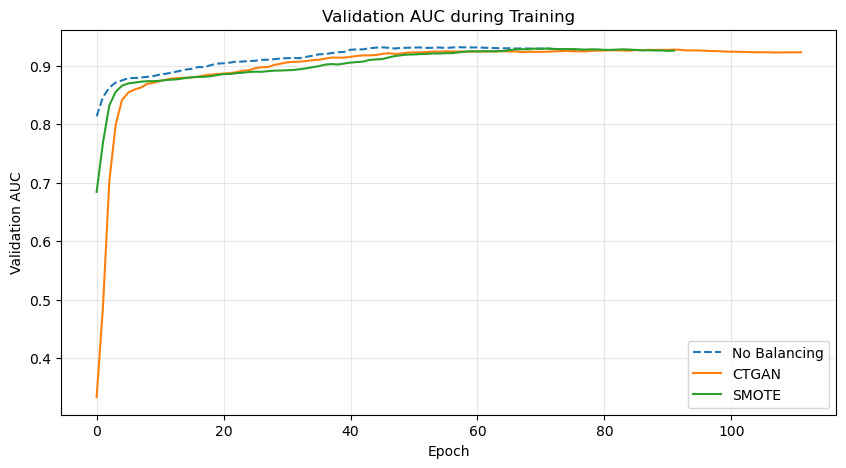

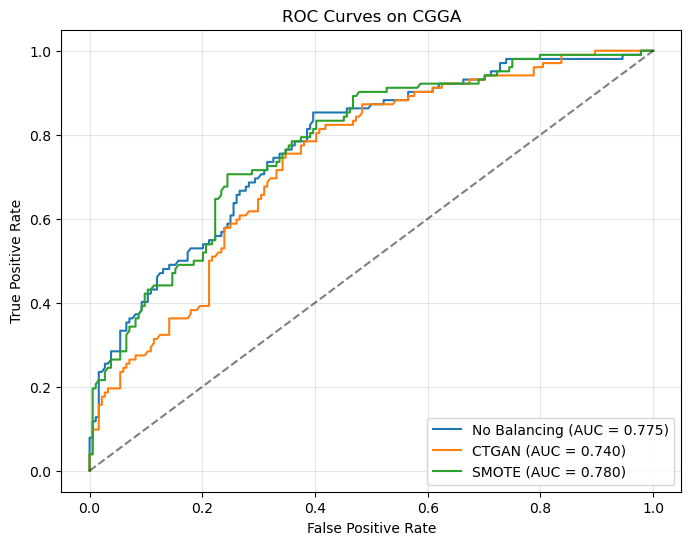

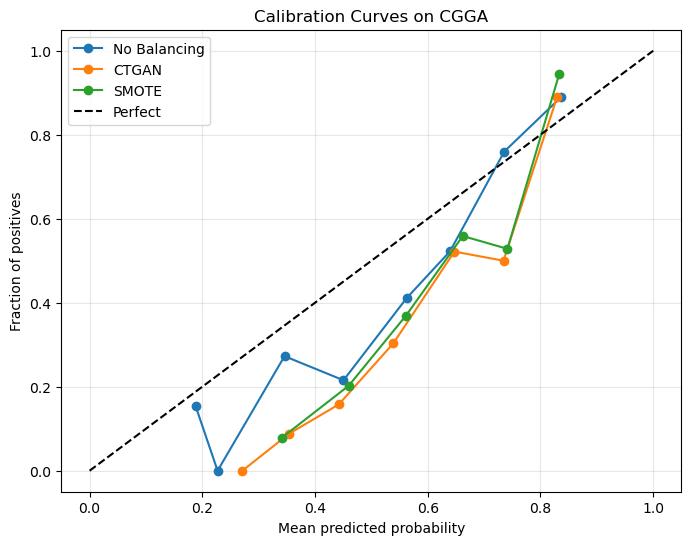

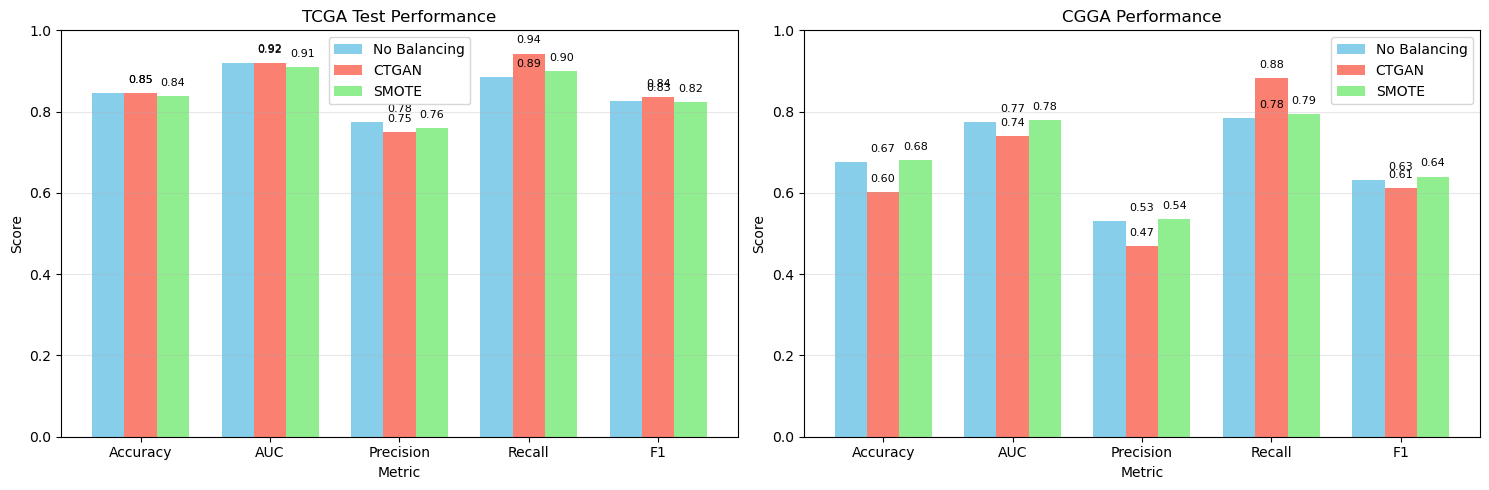

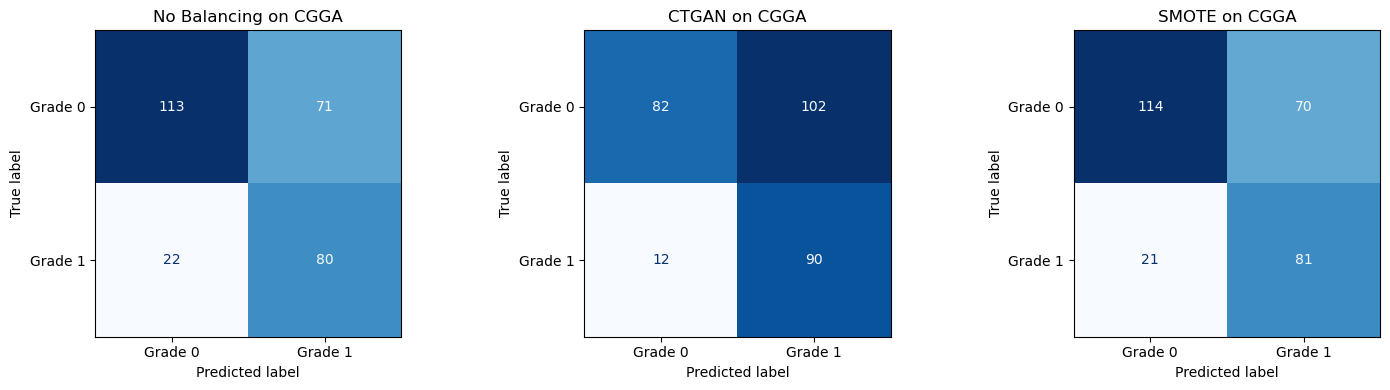


Classification Reports on CGGA:

No Balancing:
              precision    recall  f1-score   support

     Grade 0       0.84      0.61      0.71       184
     Grade 1       0.53      0.78      0.63       102

    accuracy                           0.67       286
   macro avg       0.68      0.70      0.67       286
weighted avg       0.73      0.67      0.68       286


CTGAN:
              precision    recall  f1-score   support

     Grade 0       0.87      0.45      0.59       184
     Grade 1       0.47      0.88      0.61       102

    accuracy                           0.60       286
   macro avg       0.67      0.66      0.60       286
weighted avg       0.73      0.60      0.60       286


SMOTE:
              precision    recall  f1-score   support

     Grade 0       0.84      0.62      0.71       184
     Grade 1       0.54      0.79      0.64       102

    accuracy                           0.68       286
   macro avg       0.69      0.71      0.68       286
weighted a

In [13]:
# 12.1 Validation AUC curves during training
plt.figure(figsize=(10,5))
plt.plot(val_aucs_no_bal, label='No Balancing', linestyle='--')
plt.plot(val_aucs_ctgan, label='CTGAN')
plt.plot(val_aucs_smote, label='SMOTE')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.title('Validation AUC during Training')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 12.2 ROC curves on CGGA
plt.figure(figsize=(8,6))
fpr_nb, tpr_nb, _ = roc_curve(labels_cgga_nb, probs_cgga_nb)
fpr_ct, tpr_ct, _ = roc_curve(labels_cgga_ct, probs_cgga_ct)
fpr_sm, tpr_sm, _ = roc_curve(labels_cgga_sm, probs_cgga_sm)
plt.plot(fpr_nb, tpr_nb, label=f'No Balancing (AUC = {results_df[(results_df.Method=="No Balancing") & (results_df.Dataset=="CGGA")]["AUC"].values[0]:.3f})')
plt.plot(fpr_ct, tpr_ct, label=f'CTGAN (AUC = {results_df[(results_df.Method=="CTGAN") & (results_df.Dataset=="CGGA")]["AUC"].values[0]:.3f})')
plt.plot(fpr_sm, tpr_sm, label=f'SMOTE (AUC = {results_df[(results_df.Method=="SMOTE") & (results_df.Dataset=="CGGA")]["AUC"].values[0]:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on CGGA')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 12.3 Calibration curves on CGGA
plt.figure(figsize=(8,6))
for probs, label in [(probs_cgga_nb, 'No Balancing'),
                      (probs_cgga_ct, 'CTGAN'),
                      (probs_cgga_sm, 'SMOTE')]:
    fraction, mean_pred = calibration_curve(labels_cgga_nb, probs, n_bins=10)
    plt.plot(mean_pred, fraction, marker='o', label=label)
plt.plot([0,1], [0,1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curves on CGGA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 12.4 Bar charts for all metrics on both datasets
metrics = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))  # metric positions
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15,5))

for ax, dataset in zip(axes, ['TCGA Test', 'CGGA']):
    subset = results_df[results_df.Dataset == dataset]
    nb_vals = subset[subset.Method == 'No Balancing'][metrics].values.flatten()
    ct_vals = subset[subset.Method == 'CTGAN'][metrics].values.flatten()
    sm_vals = subset[subset.Method == 'SMOTE'][metrics].values.flatten()
    
    ax.bar(x - width, nb_vals, width, label='No Balancing', color='skyblue')
    ax.bar(x, ct_vals, width, label='CTGAN', color='salmon')
    ax.bar(x + width, sm_vals, width, label='SMOTE', color='lightgreen')
    
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_title(f'{dataset} Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [nb_vals, ct_vals, sm_vals]:
        for i, val in enumerate(bars):
            ax.text(i + (0 if bars is nb_vals else (0 if bars is ct_vals else width)), 
                    val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 12.5 Confusion Matrices for all three methods on CGGA
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, model) in zip(axes, [('No Balancing', model_no_bal), ('CTGAN', model_ctgan), ('SMOTE', model_smote)]):
    with torch.no_grad():
        out = model(cgga_graph.x_dict, cgga_graph.edge_index_dict)
        preds = out.argmax(dim=1).cpu().numpy()
        labels = cgga_graph['Patient'].y.cpu().numpy()
        cm = confusion_matrix(labels, preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Grade 0', 'Grade 1'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'{name} on CGGA')
plt.tight_layout()
plt.show()

# 12.6 Classification reports as tables (optional)
print("\nClassification Reports on CGGA:")
for name, model in [('No Balancing', model_no_bal), ('CTGAN', model_ctgan), ('SMOTE', model_smote)]:
    with torch.no_grad():
        out = model(cgga_graph.x_dict, cgga_graph.edge_index_dict)
        preds = out.argmax(dim=1).cpu().numpy()
        labels = cgga_graph['Patient'].y.cpu().numpy()
        print(f"\n{name}:")
        print(classification_report(labels, preds, target_names=['Grade 0', 'Grade 1']))